# Horizontal resolution study

Compare different horizontal resolutions and see what happens to the Lamb wave,
specifically the amplitude and phase speed (Figure 8).

In [5]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib.colors as colors
import metpy
import cmaps
import matplotlib
from functions import *

In [6]:
# Note, this is currently all for the acid test.
# Read in the data.
# Now, just compare SE, FV3, and MPAS

# Save the figures?
save_the_fig = True

# SE
se_run_base = '/glade/derecho/scratch/nforcone/'

case_se30 = 'CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb'
nc_file_se30 = case_se30 + '.cam.h0i.0001-01-01-00000.nc'

case_se60 = 'CAM_6_4_089_ne60_ne60_mg16_L100_ztop50km_dz500m'
nc_file_se60 = case_se60 + '.cam.h0i.0001-01-01-00000.nc'

case_se120 = 'CAM_6_4_089_ne120_ne120_mg16_L100_ztop50km_dz500m'
nc_file_se120 = case_se120 + '.cam.h0i.0001-01-01-00000.nc'

# FV3
fv3_run_base = "/glade/derecho/scratch/timand/"

case_fv3_C96 = 'cam_6_4_095_lamb_fv3_C96_ztop_50km_dt_1min'
nc_file_fv3_C96 = case_fv3_C96 + '.cam.h0i.0001-01-01-00000_p_pert_subcycled.regrid.1x1.nc'

case_fv3_C192 = 'cam_6_4_095_lamb_fv3_C192_ztop_50km_dt_1min'
nc_file_fv3_C192 = case_fv3_C192 + '.cam.h0i.0001-01-01-00000_p_pert_subcycled.regrid.0.5x0.5.nc'

case_fv3_C384 = 'cam_6_4_095_lamb_fv3_C384_ztop_50km_dt_1min'
nc_file_fv3_C384 = case_fv3_C384 + '.cam.h0i.0001-01-01-00000_p_pert.regrid.0.25x0.25.aave.nc'

        
# MPAS
mpas_run_base = '/glade/derecho/scratch/cjablono/'  

case_mpas120 = 'cam_6_4_161.MPAS120.L100.top_50km.fadiab.pressure_perturb'
nc_file_mpas120 = case_mpas120 + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.no_diffusion.cpair_default.50hPa.nc'

case_mpas60 = 'cam_6_4_161.MPAS60.L100.top_50km.fadiab.pressure_perturb'
nc_file_mpas60 = case_mpas60 + '.cam.h0i.0001-01-01-00000.1min.regrid.0.5x0.5.18h.no_diffusion.cpair_default.50hPa.nc'

case_mpas30 = 'cam_6_4_161.MPAS30.L50.top_25km.fadiab.pressure_perturb'
nc_file_mpas30 = case_mpas30 + '.cam.h0i.0001-01-01-00000.1min.regrid.0.25x0.25.18h.no_diffusion.cpair_default.50hPa.nc'

# Load in the files

run_path_se30 = se_run_base + case_se30 + '/run/' + nc_file_se30
run_path_se60 = se_run_base + case_se60 + '/run/' + nc_file_se60
run_path_se120 = se_run_base + case_se120 + '/run/' + nc_file_se120

run_path_fv3_C96 = fv3_run_base + case_fv3_C96 + '/run/' + nc_file_fv3_C96
run_path_fv3_C192 = fv3_run_base + case_fv3_C192 + '/run/' + nc_file_fv3_C192
run_path_fv3_C384 = fv3_run_base + case_fv3_C384 + '/run/' + nc_file_fv3_C384

run_path_mpas120 = mpas_run_base + case_mpas120 + '/run/' + nc_file_mpas120
run_path_mpas60 = mpas_run_base + case_mpas60 + '/run/' + nc_file_mpas60
run_path_mpas30 = mpas_run_base + case_mpas30 + '/run/' + nc_file_mpas30

nc_se30 = Dataset(run_path_se30, 'r')
nc_se60 = Dataset(run_path_se60, 'r')
nc_se120 = Dataset(run_path_se120, 'r')

nc_fv3_C96 = Dataset(run_path_fv3_C96, 'r')
nc_fv3_C192 = Dataset(run_path_fv3_C192, 'r')
nc_fv3_C384 = Dataset(run_path_fv3_C384, 'r')

nc_mpas120 = Dataset(run_path_mpas120, 'r')
nc_mpas60 = Dataset(run_path_mpas60, 'r')
nc_mpas30 = Dataset(run_path_mpas30, 'r')


In [7]:
time = nc_se30['time'][:]

time_mins = time*24*60

# Each resolution has different lon, lat.
lat_one_deg = nc_mpas120['lat'][:]
lon_one_deg = nc_mpas120['lon'][:]

lat_half_deg = nc_mpas60['lat'][:]
lon_half_deg = nc_mpas60['lon'][:]

lat_quarter_deg = nc_mpas30['lat'][:]
lon_quarter_deg = nc_mpas30['lon'][:]


In [8]:
# Instead, plot the amplitude at the antipode at all times:
lon_a_idx_one_deg = 90
lat_a_idx_one_deg = 90

lon_a_idx_half_deg = 180
lat_a_idx_half_deg = 180

lon_a_idx_quarter_deg = 360
lat_a_idx_quarter_deg = 360

field_name = 'PS'
p0=1e5

# MPAS quarter deg seems to have regridded better, so check if I'm using poles or not.

print(np.shape(nc_se30[field_name]))
print(np.shape(nc_se60[field_name]))
print(np.shape(nc_se120[field_name]))

print(np.shape(nc_fv3_C96[field_name]))
print(np.shape(nc_fv3_C192[field_name]))
print(np.shape(nc_fv3_C384[field_name]))

print(np.shape(nc_mpas120[field_name]))
print(np.shape(nc_mpas60[field_name]))
print(np.shape(nc_mpas30[field_name]))

# Currently SE is all regridded to 1x1, but we should change this ... 
ap_se30 = nc_se30[field_name][:, lat_a_idx_one_deg, lon_a_idx_one_deg] - p0
ap_se60 = nc_se60[field_name][:, lat_a_idx_one_deg, lon_a_idx_one_deg] - p0
ap_se120 = nc_se120[field_name][:, lat_a_idx_one_deg, lon_a_idx_one_deg] - p0

ap_C96 = nc_fv3_C96[field_name][:, lat_a_idx_one_deg, lon_a_idx_one_deg] - p0
ap_C192 = nc_fv3_C192[field_name][:, lat_a_idx_half_deg, lon_a_idx_half_deg] - p0
ap_C384 = nc_fv3_C384[field_name][:, lat_a_idx_quarter_deg, lon_a_idx_quarter_deg] - p0

ap_mpas120 = nc_mpas120[field_name][:, lat_a_idx_one_deg, lon_a_idx_one_deg] - p0
ap_mpas60 = nc_mpas60[field_name][:, lat_a_idx_half_deg, lon_a_idx_half_deg] - p0
ap_mpas30 = nc_mpas30[field_name][:, lat_a_idx_quarter_deg, lon_a_idx_quarter_deg] - p0

(1081, 181, 360)
(1081, 181, 360)
(1081, 181, 360)
(1081, 181, 360)
(1081, 361, 720)
(1081, 721, 1440)
(1081, 181, 360)
(1081, 361, 720)
(1081, 721, 1440)


In [9]:
# What are the estimation speeds??
# Use the maximum method
lon_one_inds = np.array([120, 140, 160, 180, 200, 220, 240])
lon_half_inds = lon_one_inds*2
lon_quarter_inds = lon_one_inds*4

lamb_times_se30, lamb_speed_se30 = find_lamb_wave(nc_se30[field_name][:, lat_a_idx_one_deg, :] - p0, time, lon_one_deg, lon_one_inds)
lamb_times_se60, lamb_speed_se60 = find_lamb_wave(nc_se60[field_name][:, lat_a_idx_one_deg, :] - p0, time, lon_one_deg, lon_one_inds)
lamb_times_se120, lamb_speed_se120 = find_lamb_wave(nc_se120[field_name][:, lat_a_idx_one_deg, :] - p0, time, lon_one_deg, lon_one_inds)

lamb_times_C96, lamb_speed_C96 = find_lamb_wave(nc_fv3_C96[field_name][:, lat_a_idx_one_deg, :] - p0, time, lon_one_deg, lon_one_inds)
lamb_times_C192, lamb_speed_C192 = find_lamb_wave(nc_fv3_C192[field_name][:, lat_a_idx_half_deg, :] - p0, time, lon_half_deg, lon_half_inds)
lamb_times_C384, lamb_speed_C384 = find_lamb_wave(nc_fv3_C384[field_name][:, lat_a_idx_quarter_deg, :] - p0, time, lon_quarter_deg, lon_quarter_inds)

lamb_times_mpas120, lamb_speed_mpas120 = find_lamb_wave(nc_mpas120[field_name][:, lat_a_idx_one_deg, :] - p0, time, lon_one_deg, lon_one_inds)
lamb_times_mpas60, lamb_speed_mpas60 = find_lamb_wave(nc_mpas60[field_name][:, lat_a_idx_half_deg, :] - p0, time, lon_half_deg, lon_half_inds)
lamb_times_mpas30, lamb_speed_mpas30 = find_lamb_wave(nc_mpas30[field_name][:, lat_a_idx_quarter_deg, :] - p0, time, lon_quarter_deg, lon_quarter_inds)

In [10]:
print(f'se30: {lamb_speed_se30}')
print(f'se60: {lamb_speed_se60}')
print(f'se120: {lamb_speed_se120}')
print(f'C96: {lamb_speed_C96}')
print(f'C192: {lamb_speed_C192}')
print(f'C384: {lamb_speed_C384}')
print(f'mpas120: {lamb_speed_mpas120}')
print(f'mpas60: {lamb_speed_mpas60}')
print(f'mpas30: {lamb_speed_mpas30}')

se30: 328.9549143232913
se60: 328.01995979030426
se120: 328.33077973343586
C96: 326.26646157421783
C192: 327.08906602578475
C384: 327.5019257159515
mpas120: 330.1052649376562
mpas60: 331.4767054415115
mpas30: 332.21941461864196


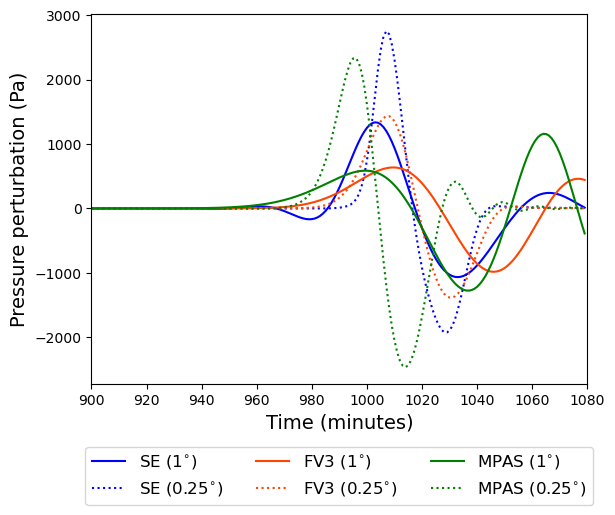

In [11]:
t_end = -1
t_min = 900

plt.figure()
plt.plot(time_mins[t_min:t_end], ap_se30[t_min:t_end], label=r'SE (1$^{\circ}$)', c='b')
#plt.plot(time_mins[t_min:t_end], ap_se60[t_min:t_end], label=f'se60: {lamb_speed_se60:.1f}' r' m s$^{-1}$', c='b',linestyle='--')
plt.plot(time_mins[t_min:t_end], ap_se120[t_min:t_end], label=r'SE (0.25$^{\circ}$)', c='b',linestyle=':')
plt.plot(time_mins[t_min:t_end], ap_C96[t_min:t_end], label=r'FV3 (1$^{\circ}$)', c='orangered')
#plt.plot(time_mins[t_min:t_end], ap_C192[t_min:t_end], label=f'C192: {lamb_speed_C192:.1f}' r' m s$^{-1}$', c='orangered',linestyle='--')
plt.plot(time_mins[t_min:t_end], ap_C384[t_min:t_end], label=r'FV3 (0.25$^{\circ}$)', c='orangered',linestyle=':')
plt.plot(time_mins[t_min:t_end], ap_mpas120[t_min:t_end], label=r'MPAS (1$^{\circ}$)', c='g')
#plt.plot(time_mins[t_min:t_end], ap_mpas60[t_min:t_end], label=f'mpas60: {lamb_speed_mpas60:.1f}' r' m s$^{-1}$', c='g',linestyle='--')
plt.plot(time_mins[t_min:t_end], ap_mpas30[t_min:t_end], label=r'MPAS (0.25$^{\circ}$)', c='g',linestyle=':')
plt.xlim([time_mins[t_min],time_mins[t_end]])
plt.ylabel('Pressure perturbation (Pa)', size=14)
plt.xlabel('Time (minutes)', size=14)
plt.legend(loc='lower center', prop={'size': 12}, bbox_to_anchor=(0.5, -0.35), ncol=3)

plt.savefig(f'figures/horiz_res_compare_dycores', bbox_inches='tight')

1081
1080.0


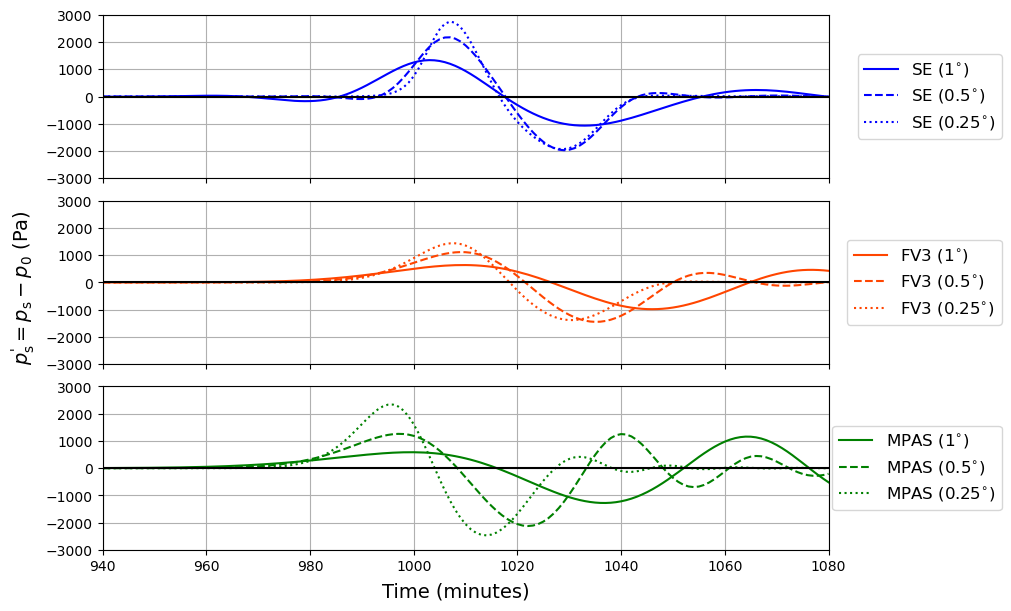

In [12]:
# What about a 3 by 1 figure for the paper? 
fig, axes = plt.subplots(3,1,constrained_layout=True, sharex=True, figsize=(10,6))
ax1, ax2, ax3 = axes

t_min = 940
t_end=-1

print(len(time))
print(time_mins[-1])

ax1.plot(time_mins[t_min:], ap_se30[t_min:], label=r'SE (1$^{\circ}$)', c='b')
ax1.plot(time_mins[t_min:], ap_se60[t_min:], label=r'SE (0.5$^{\circ}$)', c='b',linestyle='--')
ax1.plot(time_mins[t_min:], ap_se120[t_min:], label=r'SE (0.25$^{\circ}$)', c='b',linestyle=':')
ax2.plot(time_mins[t_min:], ap_C96[t_min:], label=r'FV3 (1$^{\circ}$)', c='orangered')
ax2.plot(time_mins[t_min:], ap_C192[t_min:], label=r'FV3 (0.5$^{\circ}$)', c='orangered',linestyle='--')
ax2.plot(time_mins[t_min:], ap_C384[t_min:], label=r'FV3 (0.25$^{\circ}$)', c='orangered',linestyle=':')
ax3.plot(time_mins[t_min:], ap_mpas120[t_min:], label=r'MPAS (1$^{\circ}$)', c='g')
ax3.plot(time_mins[t_min:], ap_mpas60[t_min:], label=r'MPAS (0.5$^{\circ}$)', c='g',linestyle='--')
ax3.plot(time_mins[t_min:], ap_mpas30[t_min:], label=r'MPAS (0.25$^{\circ}$)', c='g',linestyle=':')

# Black zero lines
ax1.plot(time_mins[t_min:], np.zeros(len(time_mins[t_min:])), c='k')
ax2.plot(time_mins[t_min:], np.zeros(len(time_mins[t_min:])), c='k')
ax3.plot(time_mins[t_min:], np.zeros(len(time_mins[t_min:])), c='k')

for ax in axes:
    ax.set_xlim([time_mins[t_min],time_mins[t_end]])
    ax.set_ylim([-3000, 3000])
    ax.set_yticks([-3000, -2000, -1000, 0, 1000, 2000, 3000])
    ax.grid(True)

    
fig.supylabel(r"$p_{\text{s}}^' = p_{\text{s}} - p_0$ (Pa)", size=14, y=0.53)
fig.supxlabel('Time (minutes)', size=14, x=0.45)

ax1.legend(loc='center right', prop={'size': 12}, bbox_to_anchor=(1.25, 0.5))
ax2.legend(loc='center right', prop={'size': 12}, bbox_to_anchor=(1.25, 0.5))
ax3.legend(loc='center right', prop={'size': 12}, bbox_to_anchor=(1.25, 0.5))

plt.savefig(f'figures/horiz_res_compare_dycores_3_by_1', bbox_inches='tight')